# Нейросети
MLP 128-64 с dropout, лосс MAE, таргет в шкале log1p_p995, ранняя остановка по валидации. Два варианта нормировки числовых признаков: StandardScaler и QuantileTransformer.


In [1]:
import numpy as np
import pandas as pd
import time
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

datapath = "/kaggle/input/datasets/vikakolganova/crmses/sessions_crm.parquet"
seed = 42
maxrows = 90000
np.random.seed(seed)

data = pd.read_parquet(datapath)
for c in ["start", "end", "install_datetime", "prev_session_end", "session_date"]:
    if c in data.columns:
        data[c] = pd.to_datetime(data[c], errors="coerce")
print(data.shape)

(3071996, 85)


In [2]:
targets = ["target_next_session_length_sec", "future_sessions_mean_playtime_7d"]
labels = {"target_next_session_length_sec": "next_session", "future_sessions_mean_playtime_7d": "crm_7d"}

from types import SimpleNamespace

blacklist = ["target_next_session_length_sec", "future_sessions_mean_playtime_7d", "target_log1p",
             "appmetrica_device_id", "installation_id", "session_id",
             "start", "end", "duration_hms", "session_date", "install_datetime", "prev_session_end"]

def prepare(data, target):
    d = data.sort_values("start").reset_index(drop=True)
    if len(d) > maxrows:
        d = d.tail(maxrows).reset_index(drop=True)
    feats = [c for c in d.columns if c not in blacklist and not c.startswith("target") and not c.startswith("future_")]
    catcols = [c for c in feats if not pd.api.types.is_numeric_dtype(d[c])]
    for c in feats:
        if c in catcols:
            d[c] = d[c].astype(str).fillna("unknown")
        else:
            d[c] = d[c].fillna(d[c].median())
    n = len(d)
    i = int(n * 0.70)
    j = int(n * 0.85)
    x = d[feats]
    y = d[target].values.astype(float)
    pack = SimpleNamespace(xtrain=x.iloc[:i].reset_index(drop=True),
                           xval=x.iloc[i:j].reset_index(drop=True),
                           xtest=x.iloc[j:].reset_index(drop=True),
                           ytrain=y[:i], yval=y[i:j], ytest=y[j:],
                           catcols=catcols, target=target)
    for c in catcols:
        pack.xtrain[c] = pack.xtrain[c].astype(str)
        pack.xval[c] = pack.xval[c].astype(str)
        pack.xtest[c] = pack.xtest[c].astype(str)
    return pack

packs = {t: prepare(data, t) for t in targets}
print(packs[targets[0]].xtrain.shape, packs[targets[0]].catcols)

(62999, 73) ['publisher_name', 'tracker_name', 'attributed_touch_type', 'country_iso_code', 'device_type', 'app_version_name', 'connection_type', 'traffic_source', 'install_country', 'install_device_type', 'install_app_version_name', 'install_connection_type', 'most_common_event_name', 'most_common_connection_type']


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def prodmae(yt, yp, cap=1200, tail=0.2, over=2.0, under=1.0):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    a = np.minimum(yt, cap)
    b = np.minimum(yp, cap)
    err = b - a
    w = np.where(yt > cap, tail, 1.0) * np.where(err > 0, over, under)
    return np.sum(w * np.abs(err)) / np.sum(w)

def engmae(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    ae = np.abs(yt - yp)
    w = np.select([yt <= 300, (yt > 300) & (yt <= 1200), yt > 1200], [1.0, 0.67, 0.05])
    return np.sum(w * ae) / np.sum(w)

def segmae(yt, yp, lo, hi):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    m = (yt > lo) & (yt <= hi)
    if m.any():
        return float(np.mean(np.abs(yt[m] - yp[m])))
    return np.nan

def score(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.clip(np.asarray(yp, float), 0, None)
    ae = np.abs(yt - yp)
    return {"mae": mean_absolute_error(yt, yp),
            "rmse": mean_squared_error(yt, yp) ** 0.5,
            "medae": float(np.median(ae)),
            "r2": r2_score(yt, yp),
            "p70_abs_error": float(np.percentile(ae, 70)),
            "p90_abs_error": float(np.percentile(ae, 90)),
            "product_mae": prodmae(yt, yp),
            "engagement_risk_mae": engmae(yt, yp),
            "small_mae": segmae(yt, yp, -1, 300),
            "normal_mae": segmae(yt, yp, 300, 1200),
            "long_mae": segmae(yt, yp, 1200, 1e18)}

rows = []
preds = {}

def record(target, family, name, mode, loss, yval, valpred, ytest=None, testpred=None,
           params="", btmean=np.nan, btstd=np.nan, fitsec=0.0):
    row = {"target": target, "target_label": labels.get(target, target), "model_family": family,
           "model_name": name, "objective_tag": loss, "target_mode": mode, "loss_function": loss,
           "feature_set": "all", "params": params, "fit_sec": round(fitsec, 1), "status": "ok"}
    mv = score(yval, valpred)
    for k, v in mv.items():
        row["val_" + k] = v
    if testpred is not None:
        for k, v in score(ytest, testpred).items():
            row["test_" + k] = v
        preds[(target, name)] = (np.asarray(ytest, float), np.clip(np.asarray(testpred, float), 0, None))
    row["backtest_mae_mean"] = btmean
    row["backtest_mae_std"] = btstd
    rows.append(row)
    msg = labels.get(target, target) + "  " + name + "  val_mae=" + str(round(mv["mae"], 1)) + "  r2=" + str(round(mv["r2"], 2))
    if testpred is not None:
        msg += "  test_mae=" + str(round(row["test_mae"], 1))
    print(msg)

In [4]:
def makescale(ytrain, mode):
    cap = np.percentile(np.asarray(ytrain, float), 99.5)
    if mode == "raw":
        return (lambda s: np.asarray(s, float)), (lambda s: np.asarray(s, float))
    if mode == "p995":
        return (lambda s: np.clip(np.asarray(s, float), 0, cap)), (lambda s: np.asarray(s, float))
    return (lambda s: np.log1p(np.clip(np.asarray(s, float), 0, cap))), (lambda s: np.expm1(np.asarray(s, float)))

In [5]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, QuantileTransformer
keras.utils.set_random_seed(seed)

def makemlp(nin):
    m = keras.Sequential([
        layers.Input(shape=(nin,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dense(1),
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return m

2026-06-11 22:18:53.548977: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781216333.771827      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781216333.830560      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781216334.365090      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781216334.365124      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781216334.365127      58 computation_placer.cc:177] computation placer alr

## Прогрев
Короткая тренировка чтобы gpu вышел на рабочую скорость, заодно замер времени эпохи.

In [6]:
pack = packs[targets[0]]
ncols = [c for c in pack.xtrain.columns if c not in pack.catcols]
xw = StandardScaler().fit_transform(pack.xtrain[ncols]).astype("float32")
net = makemlp(len(ncols))
net.fit(xw, np.log1p(pack.ytrain), epochs=1, batch_size=4096, verbose=0)
t0 = time.time()
net.fit(xw, np.log1p(pack.ytrain), epochs=1, batch_size=4096, verbose=0)
print("эпоха", round(time.time() - t0, 1), "сек")

2026-06-11 22:19:09.895470: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


эпоха 0.3 сек


## Обучение

In [7]:
def trainnet(pack, t, rep):
    ncols = [c for c in pack.xtrain.columns if c not in pack.catcols]
    if rep == "num_std":
        tr = StandardScaler().fit(pack.xtrain[ncols])
    else:
        tr = QuantileTransformer(output_distribution="normal", subsample=100000, random_state=seed).fit(pack.xtrain[ncols])
    xtr = tr.transform(pack.xtrain[ncols]).astype("float32")
    xvl = tr.transform(pack.xval[ncols]).astype("float32")
    xte = tr.transform(pack.xtest[ncols]).astype("float32")
    fwd, inv = makescale(pack.ytrain, "log1p_p995")
    net = makemlp(len(ncols))
    es = keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)
    t0 = time.time()
    h = net.fit(xtr, fwd(pack.ytrain), validation_data=(xvl, fwd(pack.yval)),
                epochs=20, batch_size=4096, callbacks=[es], verbose=0)
    record(t, "nn", "nn_" + rep + "_mae", "log1p_p995", "mae", pack.yval,
           inv(net.predict(xvl, verbose=0).ravel()), pack.ytest,
           inv(net.predict(xte, verbose=0).ravel()), fitsec=time.time() - t0)
    return h

hist = {}
for t in targets:
    for rep in ["num_std", "num_qt"]:
        hist[(labels[t], rep)] = trainnet(packs[t], t, rep)

next_session  nn_num_std_mae  val_mae=576.7  r2=0.03  test_mae=700.4
next_session  nn_num_qt_mae  val_mae=563.6  r2=0.02  test_mae=606.9
crm_7d  nn_num_std_mae  val_mae=328.4  r2=-0.2  test_mae=434.6
crm_7d  nn_num_qt_mae  val_mae=316.9  r2=0.12  test_mae=313.7


## Сеть под ансамбль
Отдельная сеть для ансамбля с бустингом: те же признаки num_qt, 15 эпох без ранней остановки. Предсказания сохраняю в файл, сам ансамбль собирается в ноутбуке 5.

In [8]:
pack = packs[targets[0]]
ncols = [c for c in pack.xtrain.columns if c not in pack.catcols]
qt = QuantileTransformer(output_distribution="normal", subsample=100000, random_state=seed).fit(pack.xtrain[ncols])
xtr = qt.transform(pack.xtrain[ncols]).astype("float32")
xvl = qt.transform(pack.xval[ncols]).astype("float32")
xte = qt.transform(pack.xtest[ncols]).astype("float32")
fwd, inv = makescale(pack.ytrain, "log1p_p995")
net = makemlp(len(ncols))
net.fit(xtr, fwd(pack.ytrain), epochs=15, batch_size=4096, verbose=0)
nnval = inv(net.predict(xvl, verbose=0).ravel())
nntest = inv(net.predict(xte, verbose=0).ravel())
np.savez("nnens.npz", val=nnval, test=nntest)

## Кривые обучения

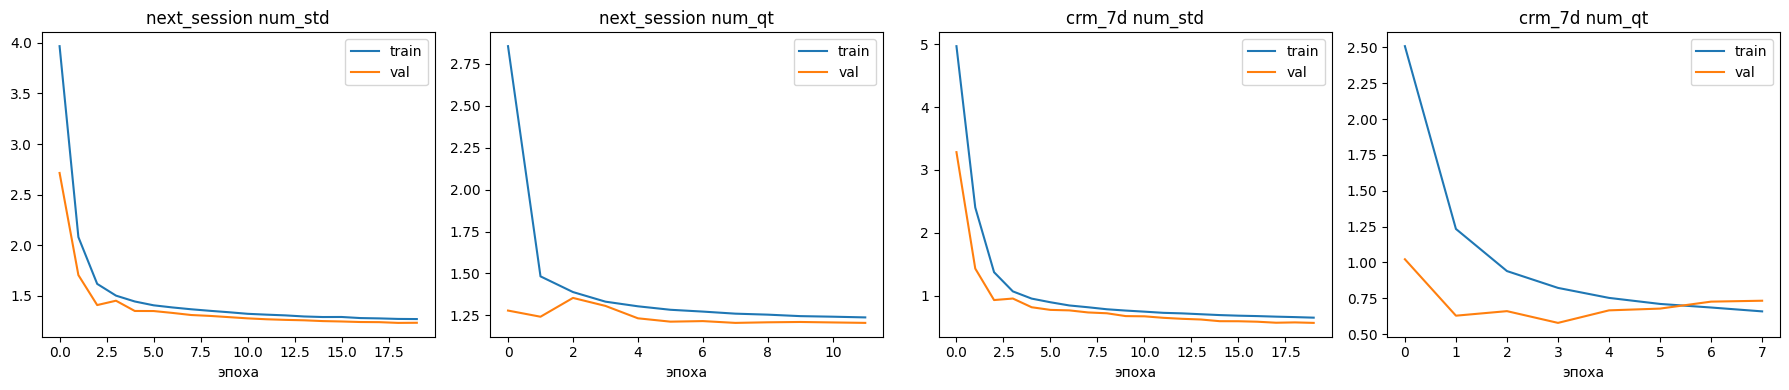

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (key, h) in zip(axes, hist.items()):
    ax.plot(h.history["loss"], label="train")
    ax.plot(h.history["val_loss"], label="val")
    ax.set_title(key[0] + " " + key[1])
    ax.set_xlabel("эпоха")
    ax.legend()
plt.tight_layout()
plt.show()

## Сколько эпох обучались

In [10]:
for key, h in hist.items():
    print(key[0], key[1], " эпох:", len(h.history["loss"]), " лучший val_loss:", round(min(h.history["val_loss"]), 4))

next_session num_std  эпох: 20  лучший val_loss: 1.2297
next_session num_qt  эпох: 12  лучший val_loss: 1.2054
crm_7d num_std  эпох: 20  лучший val_loss: 0.5688
crm_7d num_qt  эпох: 8  лучший val_loss: 0.5779


## Таблица результатов

In [11]:
res = pd.DataFrame(rows)
display(res[["target_label", "model_name", "val_mae", "val_r2", "test_mae", "test_r2", "fit_sec"]].round(2))

,target_label,model_name,val_mae,val_r2,test_mae,test_r2,fit_sec
0,next_session,nn_num_std_mae,576.69,0.03,700.36,-2.17,8.5
1,next_session,nn_num_qt_mae,563.57,0.02,606.92,0.03,6.3
2,crm_7d,nn_num_std_mae,328.38,-0.20,434.60,-1.99,8.4
3,crm_7d,nn_num_qt_mae,316.86,0.12,313.68,0.09,4.9


## Ошибки двух нормировок

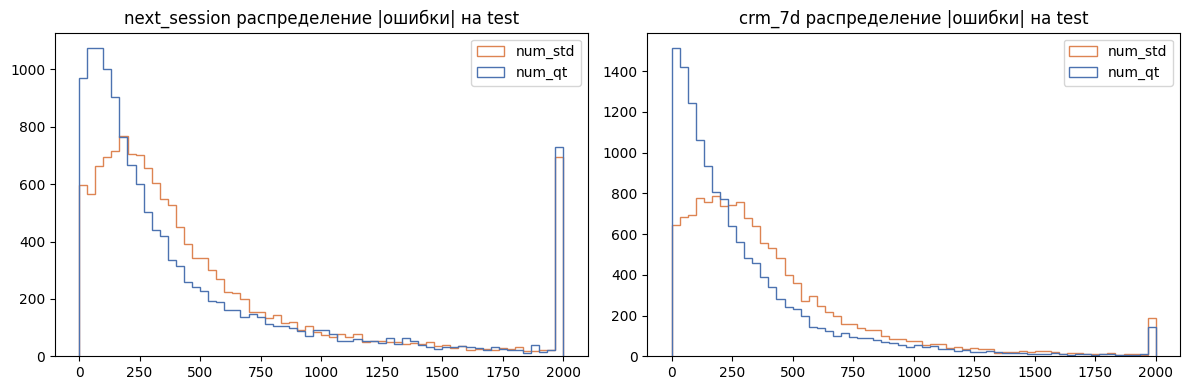

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, t in zip(axes, targets):
    for rep, col in [("num_std", "#dd8452"), ("num_qt", "#4c72b0")]:
        yt, yp = preds[(t, "nn_" + rep + "_mae")]
        ax.hist(np.clip(np.abs(yt - yp), 0, 2000), bins=60, histtype="step", lw=1.5, color=col, label=rep)
    ax.set_title(labels[t] + " распределение |ошибки| на test")
    ax.legend()
plt.tight_layout()
plt.show()

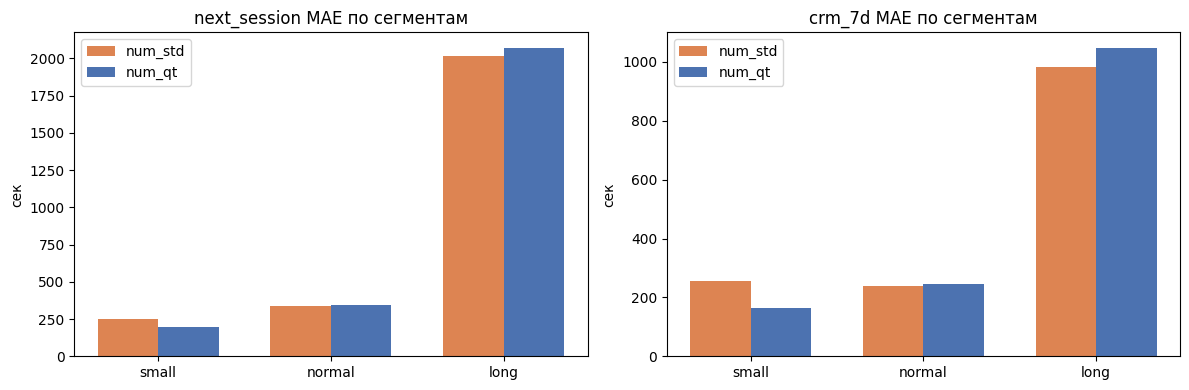

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(3)
w = 0.35
for ax, t in zip(axes, targets):
    sub = res[res["target"] == t].set_index("model_name")
    a = sub.loc["nn_num_std_mae", ["val_small_mae", "val_normal_mae", "val_long_mae"]].values
    b = sub.loc["nn_num_qt_mae", ["val_small_mae", "val_normal_mae", "val_long_mae"]].values
    ax.bar(x - w / 2, a, w, label="num_std", color="#dd8452")
    ax.bar(x + w / 2, b, w, label="num_qt", color="#4c72b0")
    ax.set_xticks(x)
    ax.set_xticklabels(["small", "normal", "long"])
    ax.set_title(labels[t] + " MAE по сегментам")
    ax.set_ylabel("сек")
    ax.legend()
plt.tight_layout()
plt.show()

## Прогноз против факта

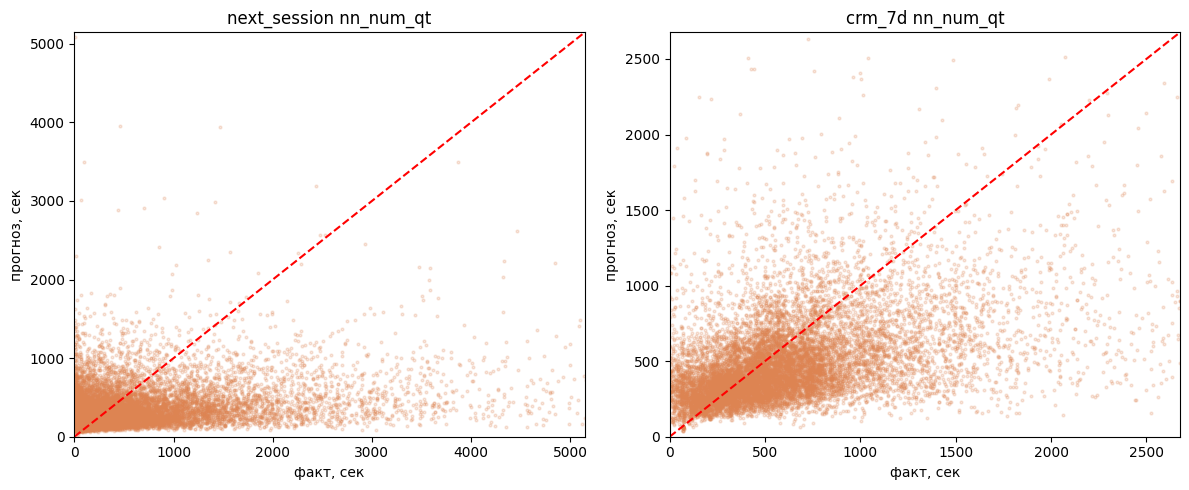

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, t in zip(axes, targets):
    yt, yp = preds[(t, "nn_num_qt_mae")]
    lim = np.percentile(yt, 99)
    ax.scatter(yt, yp, s=4, alpha=0.2, color="#dd8452")
    ax.plot([0, lim], [0, lim], "r--")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("факт, сек")
    ax.set_ylabel("прогноз, сек")
    ax.set_title(labels[t] + " nn_num_qt")
plt.tight_layout()
plt.show()

In [15]:
pd.DataFrame(rows).to_csv("nnres.csv", index=False)
out = {}
for key, val in preds.items():
    out[labels[key[0]] + "|" + key[1]] = np.vstack(val)
np.savez("nnpreds.npz", **out)